In [4]:
import sys
if ".." not in sys.path:
    sys.path.append("..")

import importlib
import config
importlib.reload(config)  # re-read config.toml every time this cell runs
cfg = config.cfg

In [5]:
import pandas as pd
import numpy as np

In [6]:
gtPath = cfg.datasetPaths.gtPath
trainPath = cfg.datasetPaths.trainPath
testPath = cfg.datasetPaths.testPath

In [7]:
gt = pd.read_csv(gtPath, sep="\t")

In [8]:
def getTrainPath(source : int, train: bool) -> str:
    if train:
        return f"{trainPath}/train_source{source}.tsv"
    else:
        return f"{testPath}/test_source{source}.tsv"

trainS1 = pd.read_csv(getTrainPath(source=1,train=True), sep="\t")
trainS2 = pd.read_csv(getTrainPath(source=2,train=True), sep="\t")
trainS3 = pd.read_csv(getTrainPath(source=3,train=True), sep="\t")

In [9]:
testS1 = pd.read_csv(getTrainPath(source=1,train=False), sep="\t")
testS2 = pd.read_csv(getTrainPath(source=2,train=False), sep="\t")
testS3 = pd.read_csv(getTrainPath(source=3,train=False), sep="\t")

In [10]:
for i in range(1,4):
    print(f"size of source {i}: ", eval(f"trainS{i}.shape"))

for i in range(1,4):
    print(f"size of test source {i}: ", eval(f"testS{i}.shape"))

size of source 1:  (2206821, 4)
size of source 2:  (5034616, 4)
size of source 3:  (5285603, 4)
size of test source 1:  (1732544, 4)
size of test source 2:  (4887273, 4)
size of test source 3:  (5082316, 4)


In [11]:
gt.info()

<class 'pandas.DataFrame'>
RangeIndex: 2206821 entries, 0 to 2206820
Data columns (total 2 columns):
 #   Column              Dtype
---  ------              -----
 0   source1_entity_id   str  
 1   matched_entity_ids  str  
dtypes: str(2)
memory usage: 150.9 MB


In [12]:
trainS1.head()

,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India


In [13]:
trainS2.head()

,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India
3,S2-163963287,Summit Inc,"GREENSBORO, NC, 19 1/2 STARDUST TRAIL",US
4,S2-49942811,Delta Tetlecommunication Inc,"914 PIERPONT AVE, CLEVELAND, OH",US


In [14]:
trainS3.head()

,entity_id,business_name,business_address,country
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US
1,S3-859268022,International South Consultants Private Ltd,NaN,India
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US
3,S3-671162755,Moyna's Coffee,"1 Ivanhoe Ave, PO Box 6009, Cincinnati, Ohio",US
4,S3-960981775,Pvt. EFS Print Ventures Ltd.,"Door No 183, 41St Cross, 22Nd Main 9Th Block J...",India


In [15]:
gt.head()

,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


In [16]:
gt.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2206821 entries, 0 to 2206820
Data columns (total 2 columns):
 #   Column              Non-Null Count    Dtype
---  ------              --------------    -----
 0   source1_entity_id   2206821 non-null  str  
 1   matched_entity_ids  2083574 non-null  str  
dtypes: str(2)
memory usage: 150.9 MB


In [17]:
#average number of matched_entities per entity in sou
numMatchedEntity = np.zeros(gt.shape[0])
for i,matched in enumerate(gt["matched_entity_ids"]):
    if pd.isna(matched):
        continue
    numMatchedEntity[i] = len(str(matched).split(","))
df = pd.DataFrame(numMatchedEntity, columns=["num_matched_entities"],dtype=int)

distribution of number of matched entities per entity in source 1:
 num_matched_entities
3     530841
4     484115
2     375212
5     321957
6     164868
0     123247
1     119157
7      63968
8      18680
9       4205
10       534
11        37
Name: count, dtype: int64


<Axes: title={'center': 'Number of matched entities per entity in source 1'}, xlabel='num_matched_entities'>

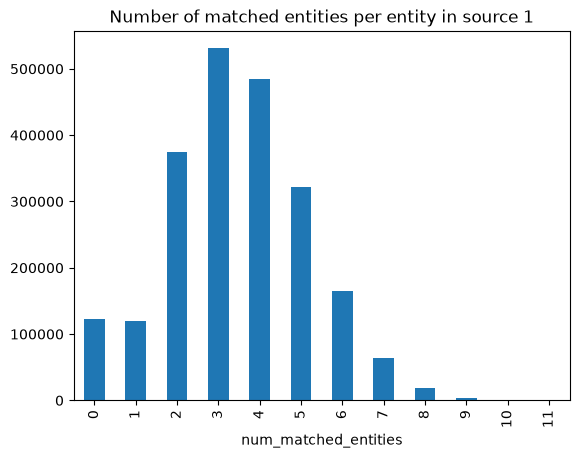

In [18]:
print("distribution of number of matched entities per entity in source 1:\n",df["num_matched_entities"].value_counts())
df["num_matched_entities"].value_counts().sort_index().plot(kind="bar", title="Number of matched entities per entity in source 1")

In [19]:
trainS1["country"].value_counts()

country
US       1323633
India     883188
Name: count, dtype: int64

In [20]:
trainS2["country"].value_counts()

country
US       3016817
India    2017799
Name: count, dtype: int64

In [21]:
trainS3["country"].value_counts()

country
US       3170056
India    2115547
Name: count, dtype: int64

In [22]:
testS1["country"].value_counts()

country
India     809986
US        663106
France    259452
Name: count, dtype: int64

In [23]:
testS2["country"].value_counts()

country
India     2312565
US        1871330
France     703378
Name: count, dtype: int64

In [24]:
testS3["country"].value_counts()

country
India     2405000
US        1945701
France     731615
Name: count, dtype: int64

In [25]:
import re, unicodedata

def clean_record(row):
    def clean(s):
        if pd.isna(s):
            return s
        s = unicodedata.normalize("NFKC", s)
        s = re.sub(r"[\u200b-\u200f\u2060\ufeff\u00ad]", "", s)            # zero-width chars
        s = s.translate(str.maketrans({"’": "'", "`": "'", "–": "-", "—": "-",
                                       "œ": "oe", "æ": "ae", "ß": "ss",
                                       "°": "o", "º": "o", "&": " and "}))
        s = unicodedata.normalize("NFKD", s)
        s = "".join(c for c in s if not (unicodedata.combining(c) and ord(c) < 0x0900))  # strip accents, keep Indic
        s = unicodedata.normalize("NFC", s).lower()
        s = re.sub(r"\b(?:[a-z]\.){2,}", lambda m: m.group().replace(".", ""), s)       # l.l.c. -> llc
        s = s.replace("'", "")                                               # orelee's -> orelees
        s = re.sub(r"[^\w\s\u0900-\u0D7F]", " ", s)                          # punctuation -> space (keep Indic)
        return " ".join(s.split())

    # domains in names: only S2/S3 have them
    name = row["business_name"]
    if not pd.isna(name):
        name = re.sub(r"\s*\|\s*(?:www\.)?\S+\.com\S*\s*$", "", name, flags=re.I)  # "Name | www.x.com" -> "Name"
        name = re.sub(r"^(?:www\.)?(\S+)\.com$", r"\1", name, flags=re.I)          # "lowerelectric.com" -> "lowerelectric"
        name = re.sub(r"^([A-Z]{7,})COM$", r"\1", name)                            # "CORALIEFETESSASCOM" -> "CORALIEFETESSAS"
        row["business_name"] = name

    row["business_name"] = clean(row["business_name"])
    row["business_address"] = clean(row["business_address"])
    return row


In [27]:
trainS2 = pd.DataFrame([clean_record(r) for r in trainS2.to_dict("records")])